In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from helper.algorithms import ClassificationAlgorithms
# joblib for seving the model
import joblib

In [12]:

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [13]:
df = pd.read_pickle("../processed_data/modelData.pkl")
df = df.drop("epoch (ms)", axis=1)

In [51]:
df_train = df.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

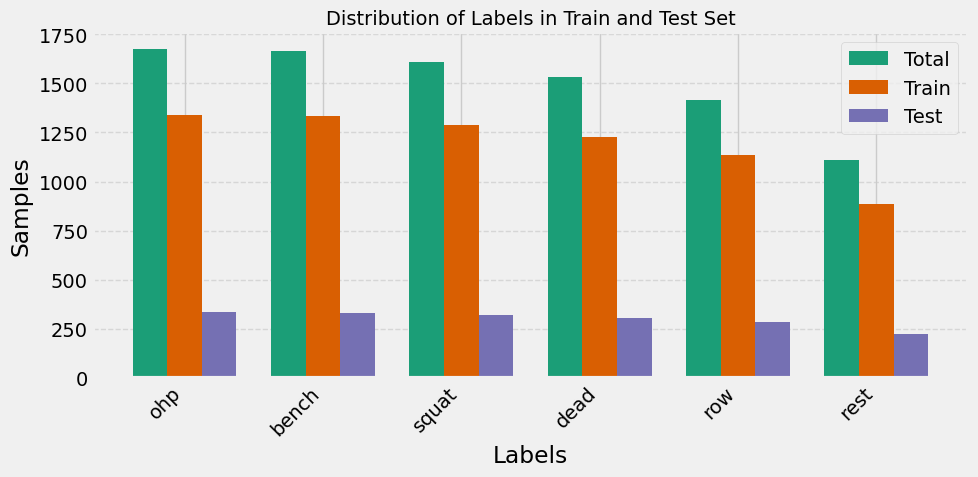

In [62]:
# Define the label order
labels = df_train["Label"].value_counts().index.tolist()

# Get counts, ensuring all labels are present
total_counts = df_train["Label"].value_counts().reindex(labels, fill_value=0)
train_counts = y_train.value_counts().reindex(labels, fill_value=0)
test_counts = y_test.value_counts().reindex(labels, fill_value=0)

# Bar width and positions
x = np.arange(len(labels))
width = 0.25

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars with manual offsets
ax.bar(x - width, total_counts, width=width, label='Total', color="#1b9e77")
ax.bar(x, train_counts, width=width, label='Train', color="#d95f02")
ax.bar(x + width, test_counts, width=width, label='Test', color="#7570b3")

# Improve appearance
ax.set_title("Distribution of Labels in Train and Test Set", fontsize=14)
ax.set_xlabel("Labels")
ax.set_ylabel("Samples")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
print("Train set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())
print("\nTotal set:")
print(df_train["Label"].value_counts())

Train set:
Label
ohp      1341
bench    1332
squat    1288
dead     1225
row      1133
rest      888
Name: count, dtype: int64

Test set:
Label
ohp      335
bench    333
squat    322
dead     306
row      284
rest     222
Name: count, dtype: int64

Total set:
Label
ohp      1676
bench    1665
squat    1610
dead     1531
row      1417
rest     1110
Name: count, dtype: int64


In [16]:
df.columns

Index(['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z', 'Gyroscope_x',
       'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label', 'Category',
       'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r', 'Gyroscope_r',
       'Accelerometer_x_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5',
       'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_x_temp_mean_ws_5',
       'Gyroscope_y_temp_mean_ws_5', 'Gyroscope_z_temp_mean_ws_5',
       'Accelerometer_r_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5',
       'cluster_acc', 'cluster_gyro'],
      dtype='object')

In [17]:
# split the features 
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))


Basic features:  6
Squere features:  2
PCA features:  3
Cluster features:  2


In [18]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + pca_feactures))
feature_set_4 = list(set(feature_set_3 + cluster_feactures))

In [19]:
# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

Starting forward selection...
Selecting feature 1/10...
After selecting feature 1/10, selected features: ['pca_1']
Selecting feature 2/10...
After selecting feature 2/10, selected features: ['pca_1', 'Accelerometer_z']
Selecting feature 3/10...
After selecting feature 3/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x']
Selecting feature 4/10...
After selecting feature 4/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5']
Selecting feature 5/10...
After selecting feature 5/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5']
Selecting feature 6/10...
After selecting feature 6/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5', 'Gyroscope_y']
Selecting feature 7/10...
After selecting feature 7/10, selected features: ['pca_1', 'Accelerometer_z', 'Acceleromet

Text(0.5, 1.0, 'Forward selection')

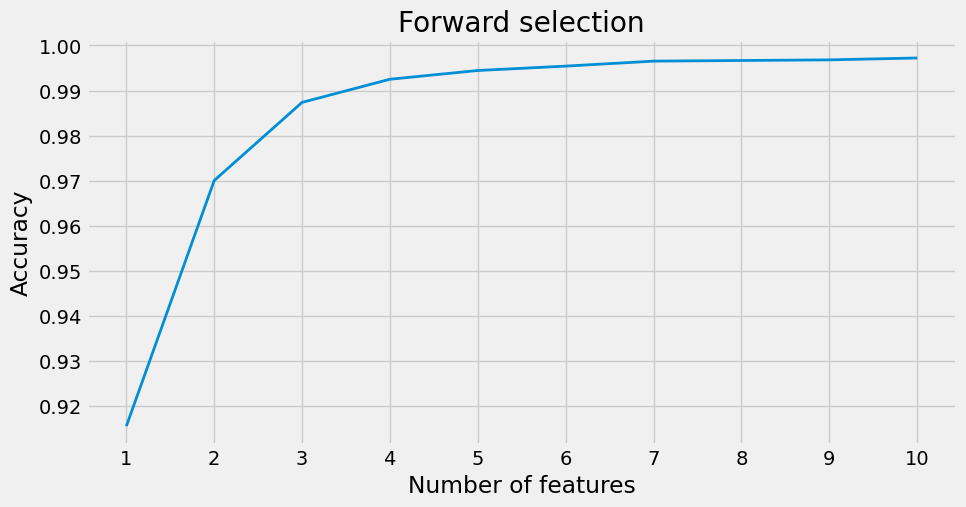

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")


In [21]:
# feature sets
possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, selected_features]
feature_names = ["Feature Set 1", "Feature Set 2", "Feature Set 3", "Feature Set 4", "Selected features"]

iterations = 1
score_df = pd.DataFrame()

# iterate over feature sets
for i, f in enumerate(feature_names):
    print(feature_names[i])
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # Random Forest
    print("\tTraining random forest")
    performance_test_rf = sum(
        accuracy_score(y_test, learner.random_forest(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])
        for _ in range(iterations)
    ) / iterations

    # KNN
    print("\tTraining KNN")
    performance_test_knn = accuracy_score(y_test, learner.k_nearest_neighbor(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Decision Tree
    print("\tTraining decision tree")
    performance_test_dt = accuracy_score(y_test, learner.decision_tree(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Naive Bayes
    print("\tTraining naive bayes")
    performance_test_nb = accuracy_score(y_test, learner.naive_bayes(selected_train_X, y_train, selected_test_X)[1])

    # SVM without kernel
    print("\tTraining SVM without kernel")
    performance_test_svm_no_kernel = accuracy_score(y_test, learner.svm_without_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # SVM with kernel
    #print("\tTraining SVM with kernel")
    #performance_test_svm_kernel = accuracy_score(y_test, learner.svm_with_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Logistic Regression
    print("\tTraining logistic regression")
    performance_test_logistic = accuracy_score(y_test, learner.logistic_regression(selected_train_X, y_train, selected_test_X)[1])

    # Save results to dataframe
    new_scores = pd.DataFrame({
        "model": ["RF", "KNN", "DT", "NB", "SVM-No-Kernel", "Logistic-Regression"], # can add SVM with kernel
        "feature_set": f,
        "accuracy": [performance_test_rf, performance_test_knn, performance_test_dt, performance_test_nb, performance_test_svm_no_kernel, performance_test_logistic], # performance_test_svm_kernel
    })
    
    score_df = pd.concat([score_df, new_scores], ignore_index=True)


Feature Set 1
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 2
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 3
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Feature Set 4
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression
Selected features
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
	Training logistic regression


In [22]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
24,RF,Selected features,0.981687
26,DT,Selected features,0.971698
12,RF,Feature Set 3,0.966149
18,RF,Feature Set 4,0.966149
6,RF,Feature Set 2,0.965594
0,RF,Feature Set 1,0.961154
20,DT,Feature Set 4,0.941731
2,DT,Feature Set 1,0.941176
8,DT,Feature Set 2,0.940067
14,DT,Feature Set 3,0.938957


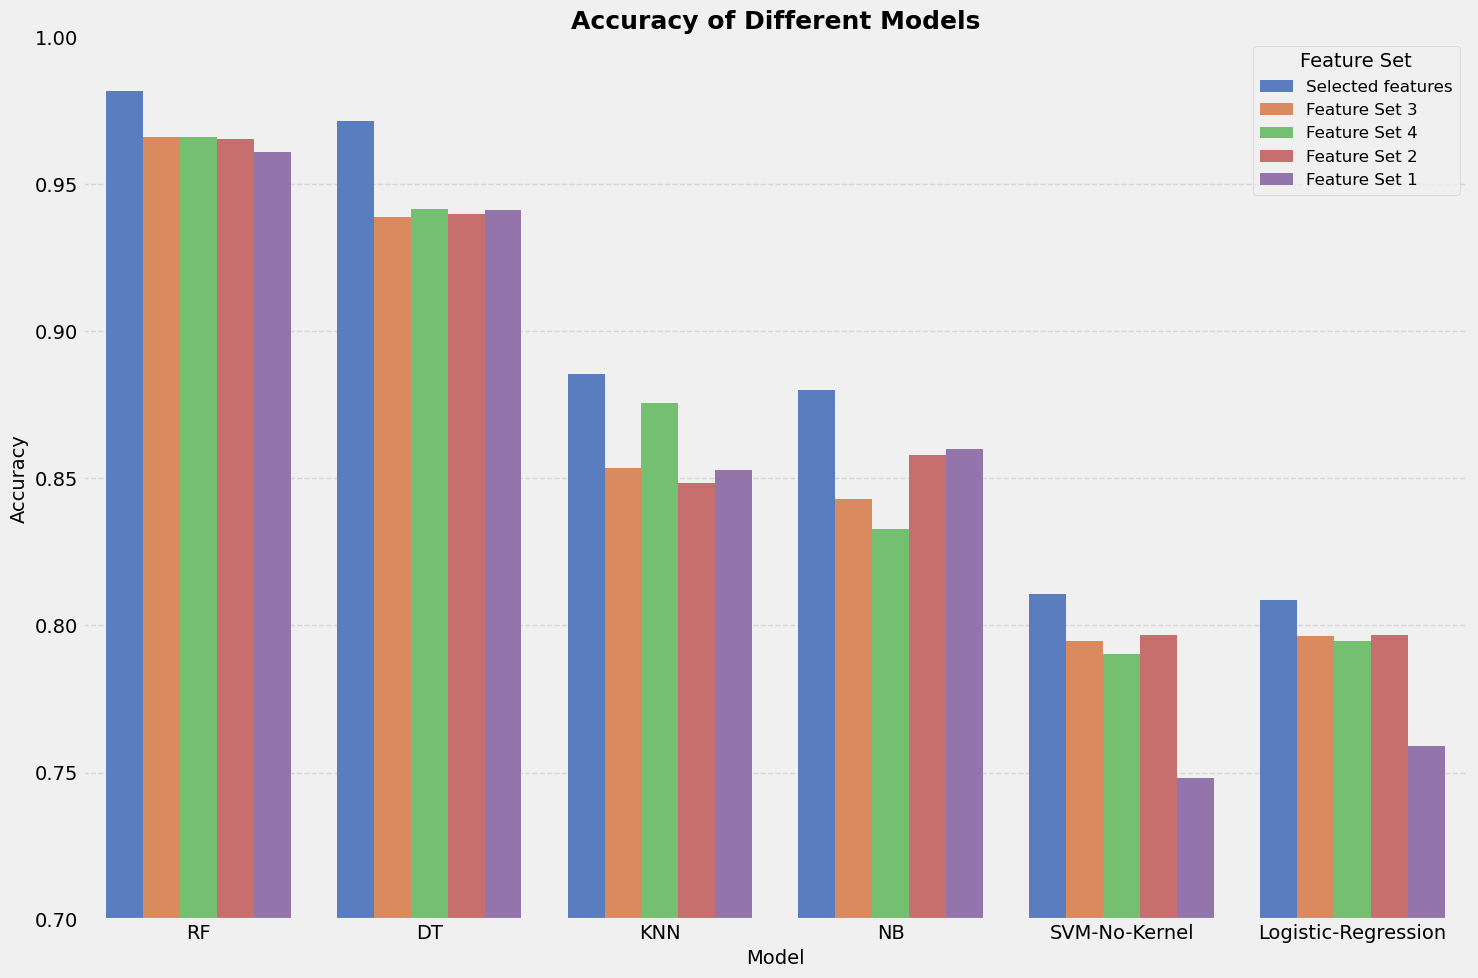

In [ ]:
plt.figure(figsize=(15, 10))
sns.set_palette("pastel")  # pastel colors
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df, palette="muted")  # use "muted" palette
plt.title("Accuracy of Different Models", fontsize=18, fontweight="bold")
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.7, 1)
plt.legend(title="Feature Set", loc="upper right", fontsize=12) 
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
# random forest
pred_train, pred_test, = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

In [25]:
# confusion matrix
cm = confusion_matrix(y_test, pred_test, labels=y.unique())
cm

array([[318,  15,   0,   0,   0,   0],
       [ 12, 322,   1,   0,   0,   0],
       [  0,   0, 322,   0,   0,   0],
       [  0,   0,   0, 302,   4,   0],
       [  0,   0,   0,   2, 282,   0],
       [  0,   0,   0,   0,   0, 222]])

In [26]:
# print accurrency on test set
accuracy_score(y_test, pred_test)

0.9811320754716981

In [27]:
report = classification_report(y_test, pred_test, labels=y.unique(), output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
bench,0.963636,0.954955,0.959276,333.000000
ohp,0.955490,0.961194,0.958333,335.000000
squat,0.996904,1.000000,0.998450,322.000000
dead,0.993421,0.986928,0.990164,306.000000
row,0.986014,0.992958,0.989474,284.000000
rest,1.000000,1.000000,1.000000,222.000000
accuracy,0.981132,0.981132,0.981132,0.981132
macro avg,0.982578,0.982672,0.982616,1802.000000
weighted avg,0.981131,0.981132,0.981122,1802.000000


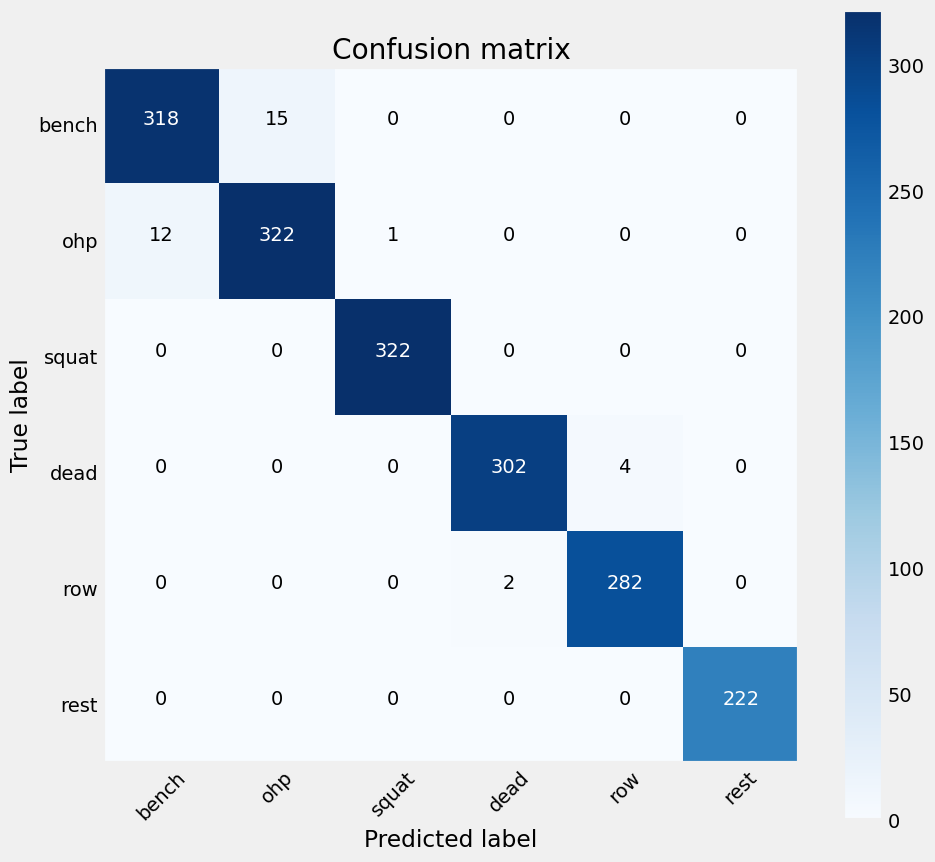

In [28]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

## Check overfitting

In [29]:
# trying the model for overfitting seeing how it proforms on the training set
cm = confusion_matrix(y_train, pred_train, labels=y.unique())
cm

array([[1328,    4,    0,    0,    0,    0],
       [   3, 1338,    0,    0,    0,    0],
       [   0,    0, 1288,    0,    0,    0],
       [   0,    0,    0, 1225,    0,    0],
       [   0,    0,    0,    0, 1133,    0],
       [   0,    0,    0,    0,    0,  888]])

In [30]:
# perint accuracy
accuracy_score(y_train, pred_train)

0.9990287220757597

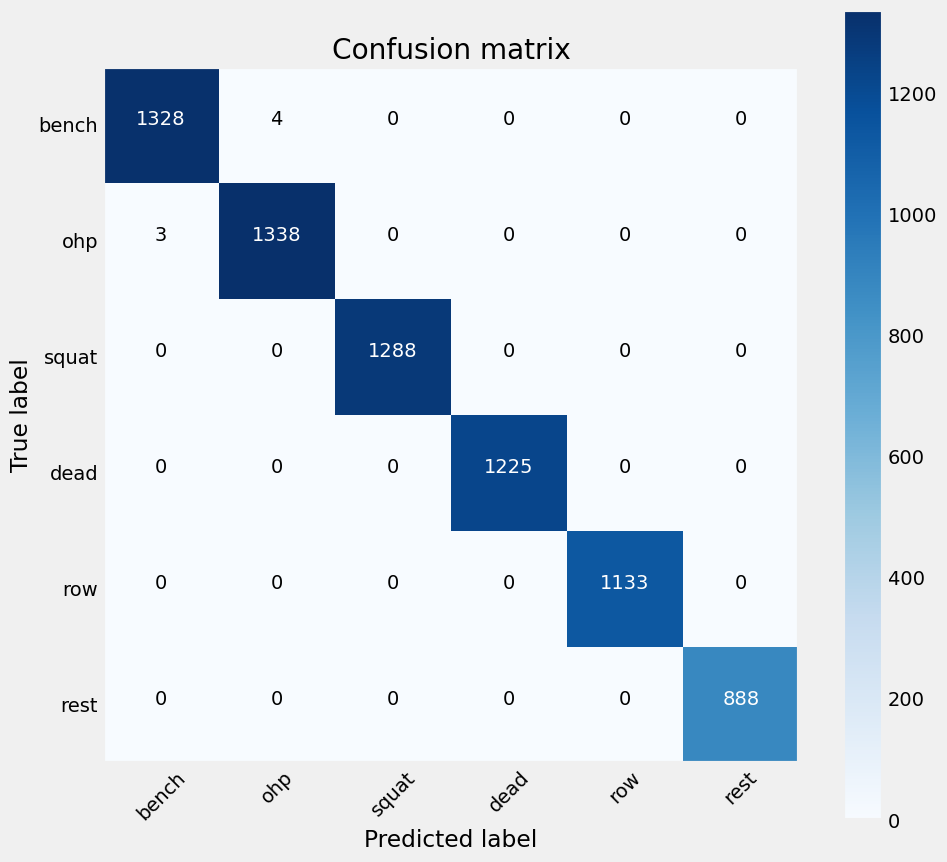

In [31]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### No Overfitting

The model performs well on both training and test datasets, showing no signs of overfitting.

- **Training Accuracy**: High accuracy on the training set.
- **Test Accuracy**: Similar accuracy on the test set with minimal drop.
- **Consistent Metrics**: Precision, recall, and F1-scores are balanced across all classes.

This indicates the model generalizes well to new data.

In [63]:
model = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

In [ ]:
# save the model
#joblib.dump(model, '../model/random_forest_model.pkl')


['../model/random_forest_model.pkl']